In [1]:
# Este comando descarga el repositorio entero a una carpeta llamada 'TFMDS' en Colab.
#!git clone https://github.com/jmorala/TFMDS.git

# Inicializar directorios
Clonar repositorio github
Posicionarse en el directorio raíz

In [2]:
import os

# Detectar si estamos en Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Configurar el directorio de trabajo según el entorno
if IN_COLAB:
    os.chdir('TFMDS')
else:
    # Detectar si estamos en Codespaces o VS Code local
    if os.path.exists('/workspaces/TFMDS'):
        # Entorno Codespaces
        os.chdir('/workspaces/TFMDS')
    else:
        # En VS Code local, nos movemos al directorio raíz del proyecto
        # Usa raw string para evitar errores de escape en rutas Windows
        current_dir = r'C:\Users\jmora\Documents\TFMDS'
        os.chdir(current_dir)

# OPCIONAL: Para verificar que estás en la ruta correcta y ver las carpetas
print("Directorio de trabajo actual:", os.getcwd())

Directorio de trabajo actual: C:\Users\jmora\Documents\TFMDS


In [3]:


import pandas as pd
import numpy as np
import optuna
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import warnings
import time
warnings.filterwarnings('ignore')

# ============================================================================
# IMPORTAR FUNCIONES PERSONALIZADAS
# ============================================================================

from lib.metricas import calcular_metricas, comparar_metricas, resumen_metricas, agregar_estadisticas_error, resumen_final_modelos
from lib.graficos import (grafico_real_vs_prediccion, grafico_scatter_prediccion, grafico_comparacion_metricas,
                          grafico_distribucion_error, grafico_feature_importance, dashboard_prediccion)


## Lectura de fichero y adaptación de los tipos


In [4]:

# ============================================================================
# LECTURA DE DATOS
# ============================================================================

df_train = pd.read_csv('datos/df_train.csv', sep=';', parse_dates=['idSecuencia'])
df_test = pd.read_csv('datos/df_test.csv', sep=';', parse_dates=['idSecuencia'])

print("\nInformación de las columnas y tipos de datos:")
print(df_train.info())
print(df_test.info())



Información de las columnas y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625800 entries, 0 to 625799
Data columns (total 23 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   idSecuencia       625800 non-null  datetime64[ns]
 1   producto          625800 non-null  int64         
 2   udsVenta          625800 non-null  int64         
 3   bolPromocion      625800 non-null  int64         
 4   bolOpen           625800 non-null  int64         
 5   bolHoliday        625800 non-null  int64         
 6   udsStock          625800 non-null  int64         
 7   rotura_stock      625800 non-null  bool          
 8   dia_semana        625800 non-null  int64         
 9   mes               625800 non-null  int64         
 10  semana            625800 non-null  int64         
 11  lag_ventas_1      625800 non-null  float64       
 12  lag_ventas_2      625800 non-null  float64       
 13  lag_ventas_3

# CatBoost

El algoritmo **CatBoost** (Categorical Boosting) es una implementación altamente eficiente, escalable y robusta de los **Gradient Boosting Decision Trees (GBDT)**, desarrollado por Yandex. Es un potente método de **aprendizaje de conjunto (*ensemble*)** que utiliza la estrategia de **Boosting**.

CatBoost es una alternativa recomendada para XGBoost y LightGBM, siendo reconocido por su alto rendimiento, especialmente en tareas con una gran cantidad de características categóricas.

Bases del Algoritmo CatBoost

1.  **Mecanismo de Conjunto (Boosting Secuencial):**
    *   Al igual que otras implementaciones de GBDT, CatBoost entrena secuencialmente una serie de árboles de decisión, donde cada nuevo árbol se enfoca en **corregir los errores** de la suma acumulada de los modelos anteriores.

2.  **Manejo Nativo de Características Categóricas (Innovación Principal):**
    *   La característica más distintiva de CatBoost es su **soporte nativo para variables categóricas** (*out of the box*). No requiere pre-codificación manual de estas características antes del entrenamiento.
    *   CatBoost transforma las características categóricas en valores numéricos **internamente**. Este proceso utiliza un método único de codificación que es similar al **alisado aditivo** (*additive smoothing*).

3.  **Eficiencia y Robustez:**
    *   CatBoost está diseñado para ser eficiente y es una de las implementaciones que se recomienda considerar para **grandes conjuntos de datos de series temporales**.
    *   Junto con LightGBM, CatBoost a menudo se menciona como una de las implementaciones que ha logrado **superar las métricas de XGBoost** en ciertos casos.
    *   El algoritmo también **maneja los valores faltantes de forma nativa**.

En resumen, CatBoost sobresale de sus competidores por su **tratamiento avanzado y robusto de las variables categóricas** directamente en el proceso de *boosting*, lo que elimina la necesidad de ingeniería de características manual para estos tipos de datos y produce un modelo final muy preciso.




# Prearación de datos

In [5]:

# Eliminar días que la tienda está cerrada
df_train = df_train[df_train['bolOpen'] == 1].copy()
df_test = df_test[df_test['bolOpen'] == 1].copy()


In [6]:

# ============================================================================
# CONFIGURACIÓN INICIAL
# ============================================================================

FEATURES = [
    'producto_encoded', 'bolPromocion', 'bolHoliday', 'Cluster',
    'dia_semana', 'mes',
    'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4',
    'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7',
    'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA'
]

TARGET = 'udsVenta'

todas_metricas = []

print("="*100)
print("🚀 INICIANDO ANÁLISIS COMPLETO DE CATBOOST")
print("="*100)


🚀 INICIANDO ANÁLISIS COMPLETO DE CATBOOST


# CatBoost global
modelo sobre todas la fechas y productos
Se va utilizar Optuna para buscar los mejores hiperparámetros.
Estos parámetros se utilizarán en los próximos modelos de Random Forest para cluster y productos, se asume que posiblemente serán los mismos parámetros, no se palntea utilizar optuna en el resto de modelos por el coste de tiempo que lleva

In [7]:

# ============================================================================
# 1. MODELO GLOBAL CON OPTUNA (CatBoost)
# ============================================================================

print("\n" + "="*100)
print("🔍 MODELO 1: CATBOOST GLOBAL")
print("="*100)

# Preparar datos
X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test = df_test[FEATURES]
y_test = df_test[TARGET]

print(f"\n✅ X_train shape: {X_train.shape}")
print(f"✅ X_test shape: {X_test.shape}")

# Último 20% como validación temporal
VAL_SIZE = int(len(X_train) * 0.2)

X_tr = X_train.iloc[:-VAL_SIZE]
y_tr = y_train.iloc[:-VAL_SIZE]

X_val = X_train.iloc[-VAL_SIZE:]
y_val = y_train.iloc[-VAL_SIZE:]

print(f"\n✅ X_tr shape: {X_tr.shape}")
print(f"✅ X_val shape: {X_val.shape}")
print(f"✅ y_tr shape: {y_tr.shape}")
print(f"✅ y_val shape: {y_val.shape}")



🔍 MODELO 1: CATBOOST GLOBAL

✅ X_train shape: (521202, 16)
✅ X_test shape: (23244, 16)

✅ X_tr shape: (416962, 16)
✅ X_val shape: (104240, 16)
✅ y_tr shape: (416962,)
✅ y_val shape: (104240,)


In [8]:
print("\n🔎 Búsqueda de hiperparámetros con Optuna para CatBoost...")

# =====================================================
#  FUNCION OBJETIVO DE OPTUNA PARA CATBOOST
# =====================================================

def objective_catboost(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 0, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'random_seed': 42,
        'verbose': False,
        'early_stopping_rounds': 50
    }

    model = CatBoostRegressor(**params)
    
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        verbose=False
    )
    
    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    return mse

# =====================================================
#  EJECUTAR OPTUNA
# =====================================================
print("\n🔍 Iniciando optimización de hiperparámetros con Optuna para CatBoost...")
start_time = time.perf_counter()

study_catboost = optuna.create_study(direction='minimize')
study_catboost.optimize(objective_catboost, n_trials=5, n_jobs=1)

elapsed = time.perf_counter() - start_time
print(f"✅ Optuna completado en {elapsed:.2f} segundos")

print("\n🏆 Mejores hiperparámetros CatBoost:")
print(study_catboost.best_params)


[I 2025-12-05 13:01:50,459] A new study created in memory with name: no-name-79df5f53-6626-4d72-bd35-9bb02be88254



🔎 Búsqueda de hiperparámetros con Optuna para CatBoost...

🔍 Iniciando optimización de hiperparámetros con Optuna para CatBoost...


[I 2025-12-05 13:02:12,291] Trial 0 finished with value: 3.880441221139438 and parameters: {'iterations': 464, 'learning_rate': 0.17791192849520626, 'depth': 9, 'l2_leaf_reg': 8.99433221026137, 'bagging_temperature': 0.05328386801989837, 'random_strength': 4.798083404173426, 'border_count': 78, 'min_data_in_leaf': 88}. Best is trial 0 with value: 3.880441221139438.
[I 2025-12-05 13:03:31,859] Trial 1 finished with value: 3.8971235217873623 and parameters: {'iterations': 864, 'learning_rate': 0.011429425409698202, 'depth': 10, 'l2_leaf_reg': 1.076392872190945, 'bagging_temperature': 0.06081262474355442, 'random_strength': 9.958839375741663, 'border_count': 150, 'min_data_in_leaf': 71}. Best is trial 0 with value: 3.880441221139438.
[I 2025-12-05 13:03:44,110] Trial 2 finished with value: 3.900114544764792 and parameters: {'iterations': 314, 'learning_rate': 0.02722118726950189, 'depth': 5, 'l2_leaf_reg': 6.481071304961232, 'bagging_temperature': 0.8560699378288343, 'random_strength': 0.

✅ Optuna completado en 167.46 segundos

🏆 Mejores hiperparámetros CatBoost:
{'iterations': 415, 'learning_rate': 0.05197082273614812, 'depth': 9, 'l2_leaf_reg': 3.5237487008124044, 'bagging_temperature': 0.9470836990211635, 'random_strength': 1.7383715619827078, 'border_count': 74, 'min_data_in_leaf': 20}


In [9]:
best_catboost = CatBoostRegressor(
    **study_catboost.best_params,
    random_state=42)

best_catboost.fit(X_train, y_train, verbose=False)


In [10]:

from lib.utils import obtener_top_productos_por_cluster

# Predicciones
y_test_pred = best_catboost.predict(X_test)

# Calcular métricas
metricas_test_global = calcular_metricas(
    y_test, y_test_pred,
    algoritmo='CatBoost', ndetalle='Global', cluster=None, producto=None)

todas_metricas.append(metricas_test_global)

print("\n📊 Métricas del Modelo Global:")
resumen_metricas([metricas_test_global])

# Calcular métricas por cluster y guardar
for cluster in df_test['Cluster'].unique():
    y_test_pred_cl = y_test_pred[X_test['Cluster'] == cluster]
    y_test_cl = y_test[X_test['Cluster'] == cluster]
    metricas_cluster = calcular_metricas(
        y_test_cl, y_test_pred_cl,
        algoritmo='CatBoost', ndetalle='Global', cluster= cluster, producto=None)
    todas_metricas.append(metricas_cluster)
    
# Calcular métricas por producto top en cada cluster
top_productos = obtener_top_productos_por_cluster(
    df=df_train,
    col_ventas='udsVenta',
    col_cluster='Cluster',
    col_producto='producto',
    n_productos=2
)

for cluster, productos in top_productos.items():
    for producto in productos:
        idx_producto = (df_test['Cluster'] == cluster) & (df_test['producto'] == producto)
        y_test_prod = y_test[idx_producto]
        y_test_pred_prod = y_test_pred[idx_producto]
        metricas_producto = calcular_metricas(
            y_test_prod, y_test_pred_prod,
            algoritmo='CatBoost',
            ndetalle='Global', cluster=cluster, producto=producto) 

resumen_metricas(todas_metricas)    





📊 Métricas del Modelo Global:

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle Cluster Producto    MAE  RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost   Global    None     None 1.5707 2.365 0.2701      49.6      144.6 0.7248    96.19

🏆 Mejor modelo: CatBoost (RMSE: 2.3650)

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost   Global      3.0     None 1.0828 1.6440 0.0943     55.20     168.92 0.7377   133.33
 CatBoost   Global      NaN     None 1.5707 2.3650 0.2701     49.60     144.60 0.7248    96.19
 CatBoost   Global      0.0     None 1.8045 2.5403 0.1233     40.38     126.07 0.7302    93.45
 CatBoost   Global      1.0     None 2.7674 3.5843 0.1455     55.30      98.76 0.7164    72.58
 CatBoost   Global      2.0     None 3.6075 5.1418 0.1830     70.48      80.96 0.7150    62.82

🏆 Mejor modelo: CatBoost (RMSE: 1.6440)


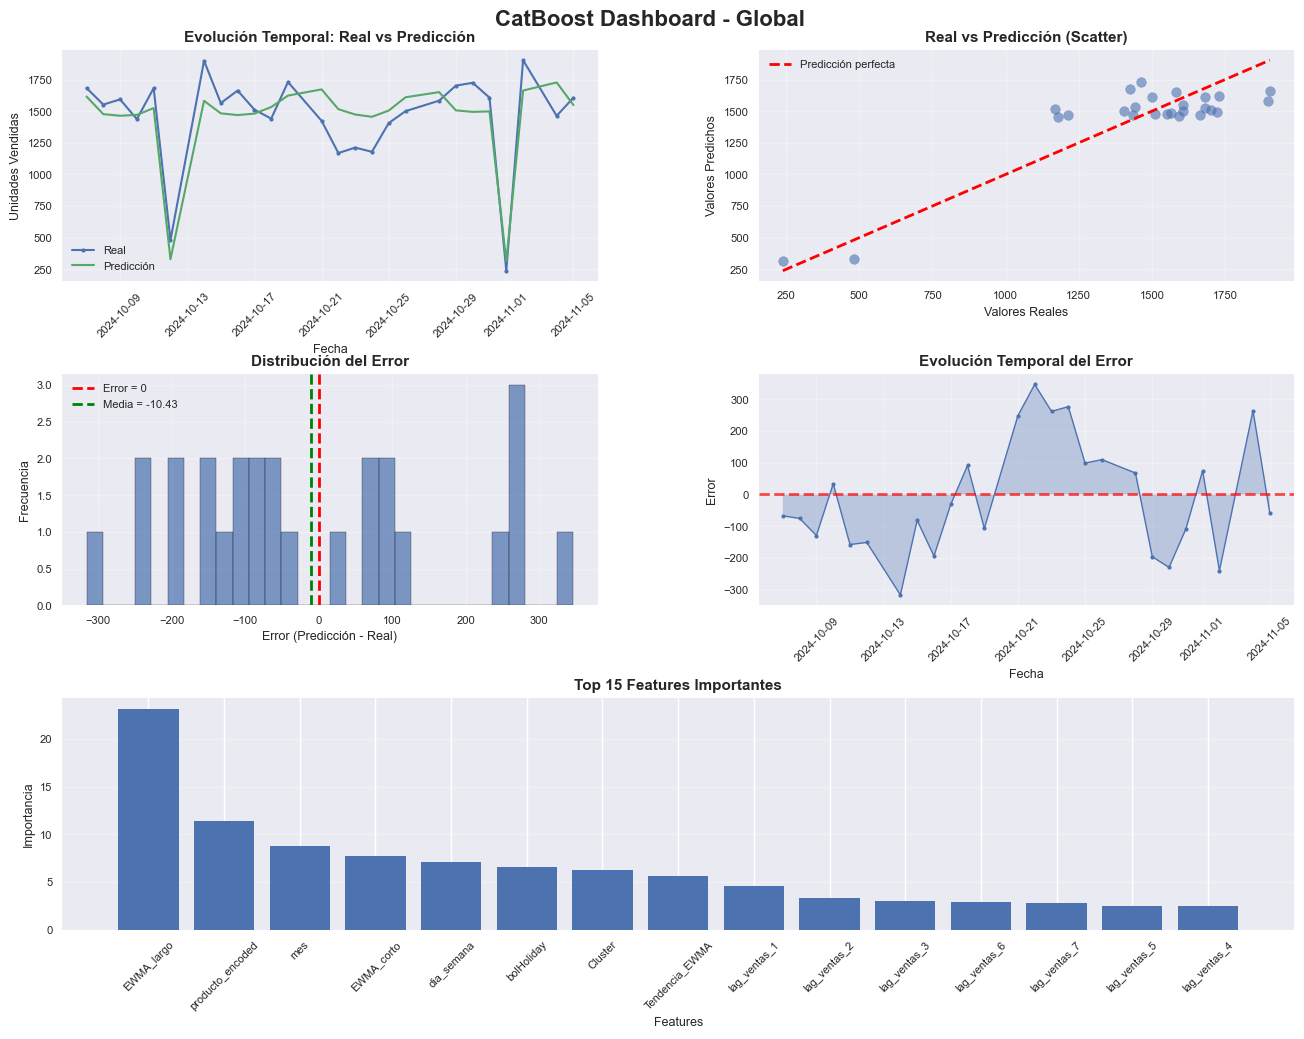

In [11]:

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

# Visualizaciones del modelo global
df_test_viz = df_test.copy()
df_test_viz['prediccion'] = y_test_pred
#df_test_viz['error'] = y_test_pred - df_test_viz[TARGET]
df_test_viz_sum = df_test_viz.groupby('idSecuencia')[[TARGET, 'prediccion']].sum().reset_index()
df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum[TARGET]

dashboard_prediccion(
        df=df_test_viz_sum,
        col_fecha='idSecuencia',
        col_real=TARGET,
        col_pred='prediccion',
        modelo=best_catboost,
        feature_names=FEATURES,
        titulo_principal=f'CatBoost Dashboard - Global'
        )


# CatBoost por Cluster


🔍 MODELO 2: CATBOOST POR CLUSTER

🔄 Entrenando modelo para Cluster 0...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost  Cluster        0     None 1.8073 2.5402 0.1234     39.88     125.83 0.7302     93.6

🏆 Mejor modelo: CatBoost (RMSE: 2.5402)


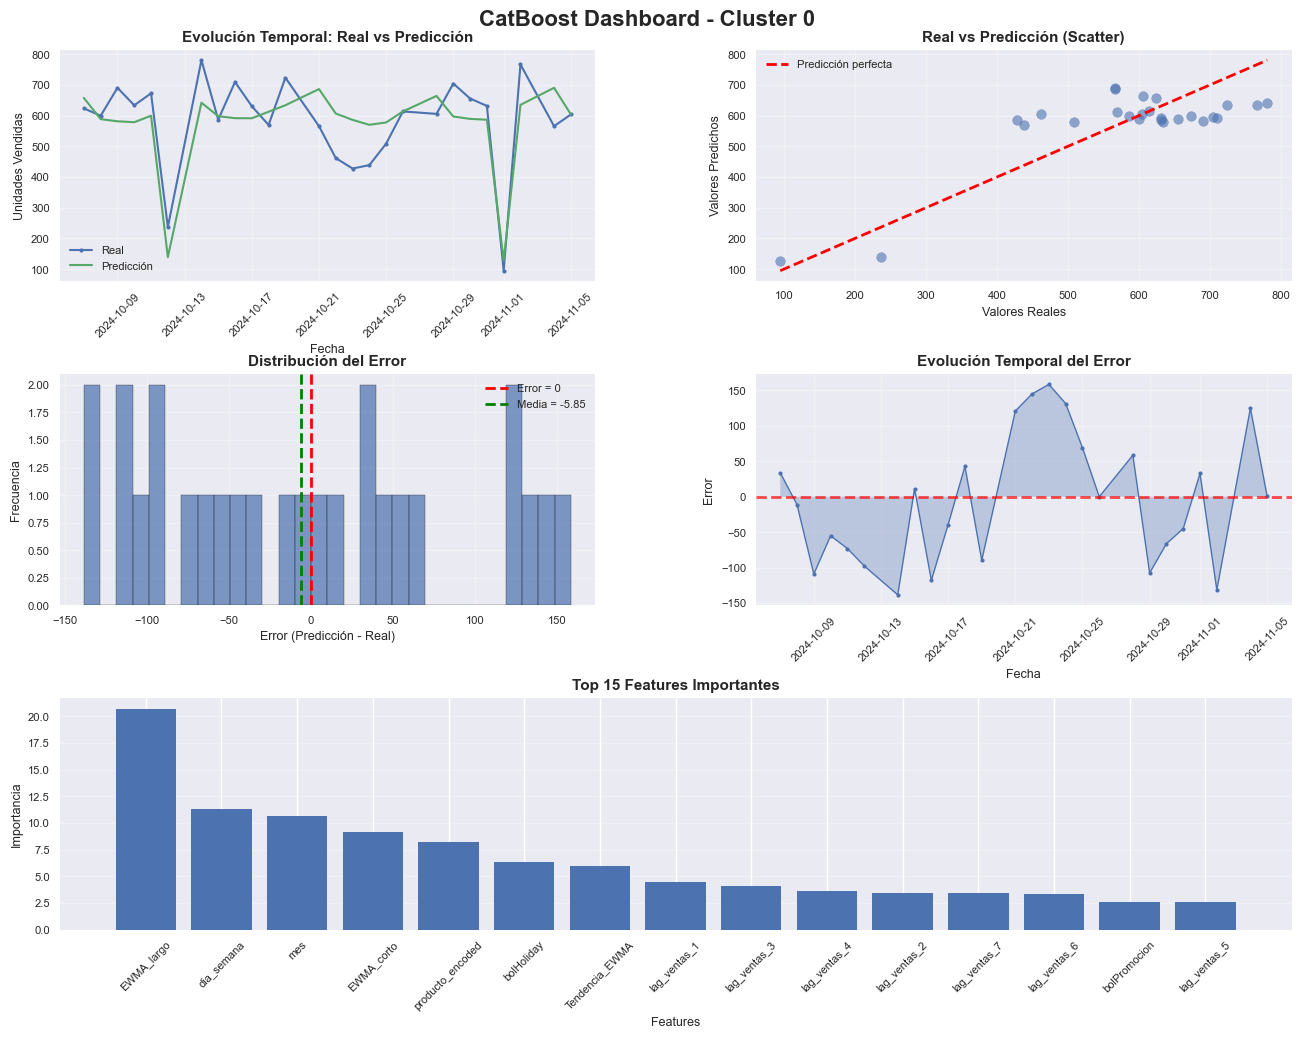


🔄 Entrenando modelo para Cluster 1...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost  Cluster        1     None 2.7666 3.5857 0.1448      55.3       98.6 0.7167    72.55

🏆 Mejor modelo: CatBoost (RMSE: 3.5857)


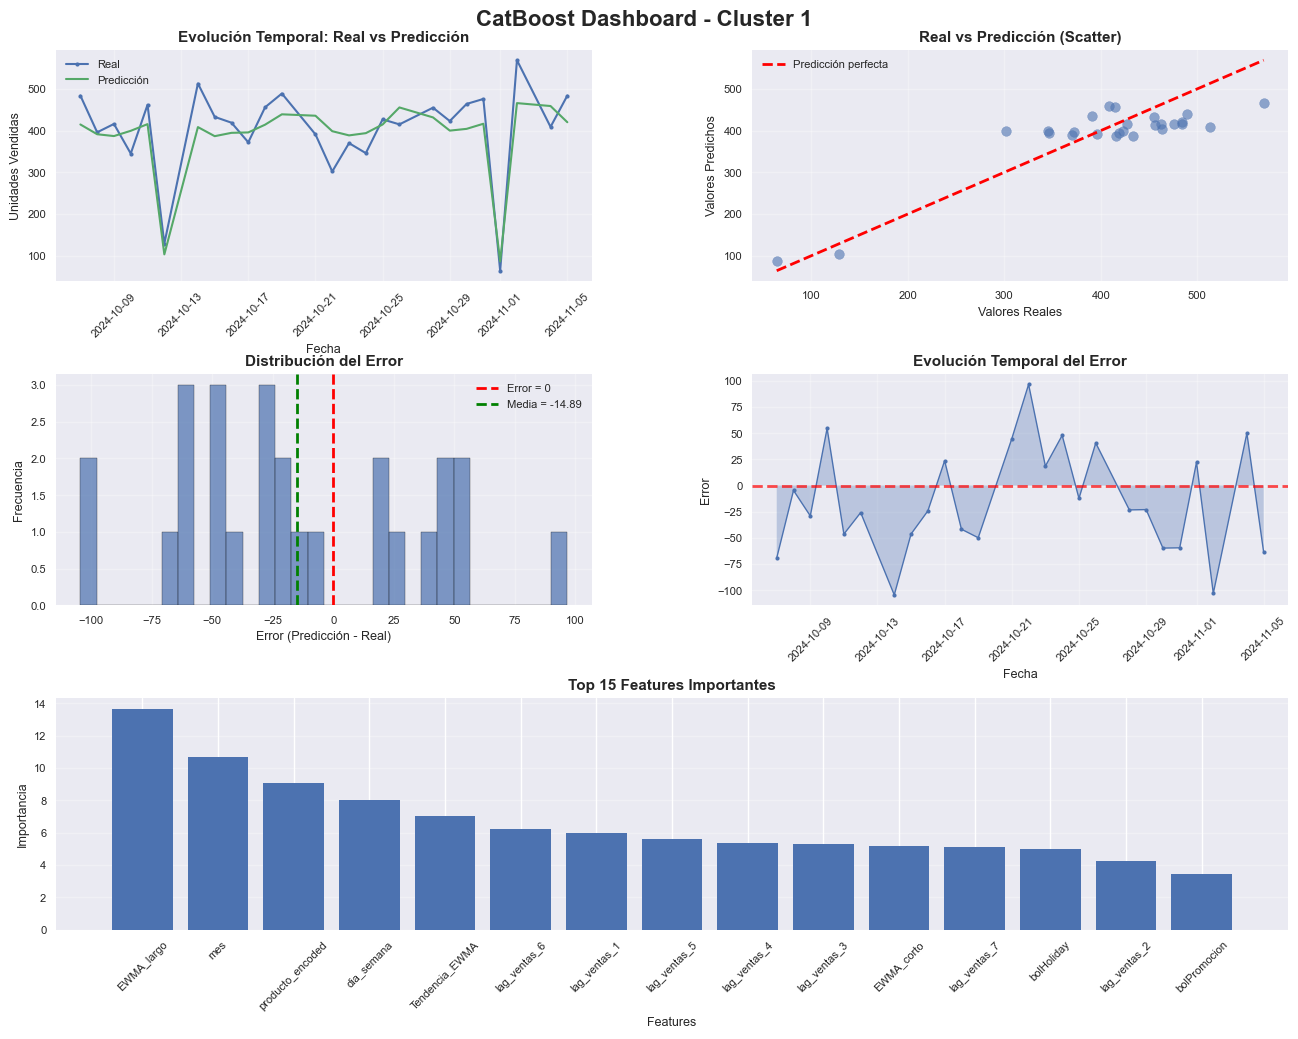


🔄 Entrenando modelo para Cluster 2...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE    R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost  Cluster        2     None 3.6657 5.1449 0.182     73.69      81.45 0.7155    63.83

🏆 Mejor modelo: CatBoost (RMSE: 5.1449)


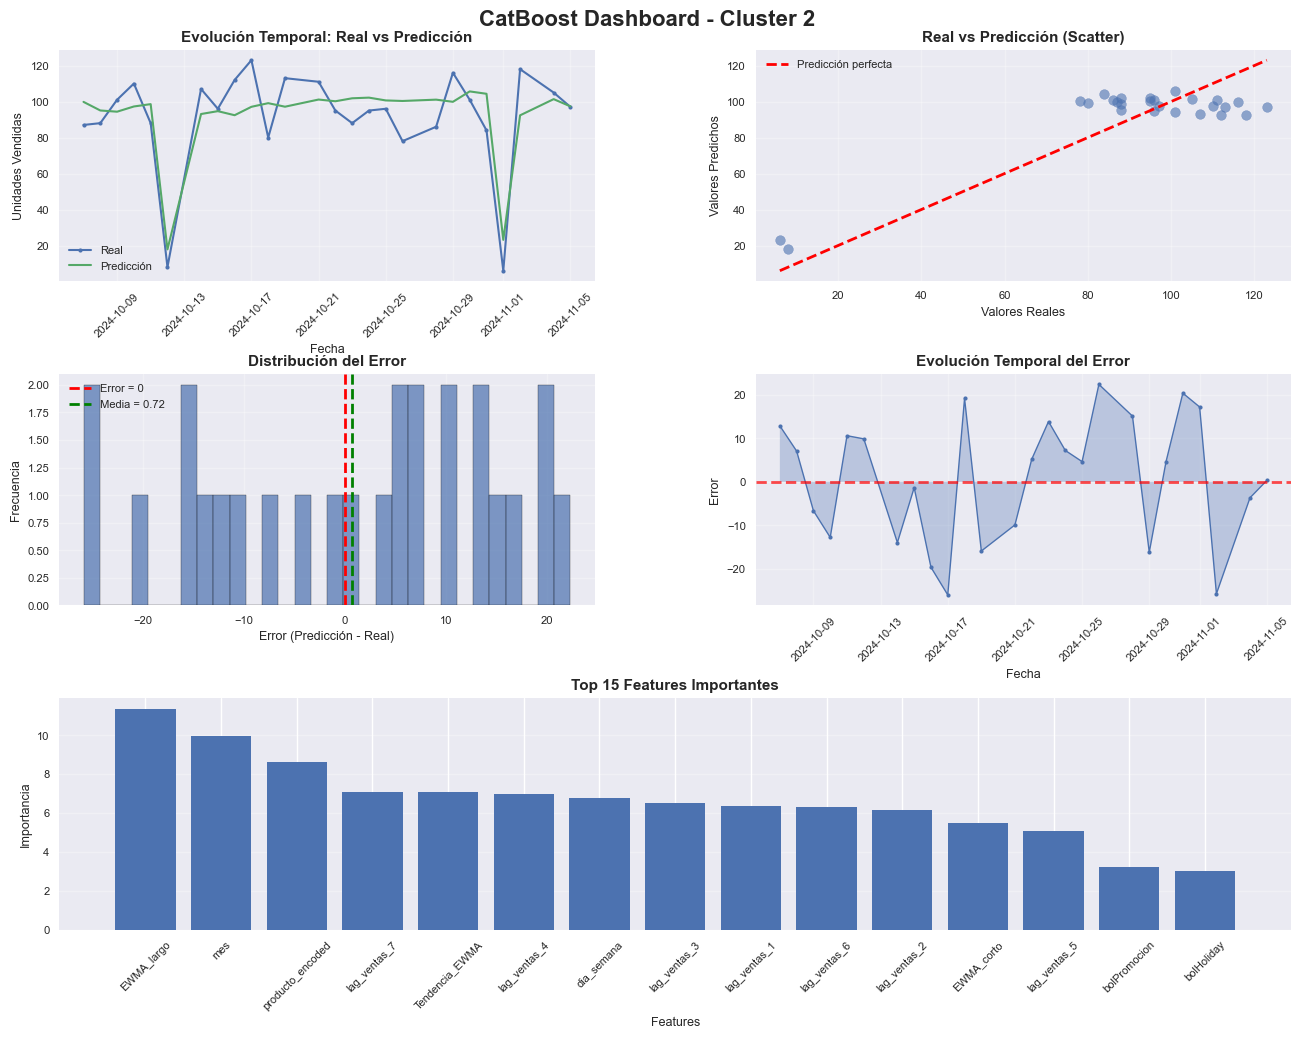


🔄 Entrenando modelo para Cluster 3...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost  Cluster        3     None 1.0833 1.6509 0.0868     55.31     168.99 0.7408   133.39

🏆 Mejor modelo: CatBoost (RMSE: 1.6509)


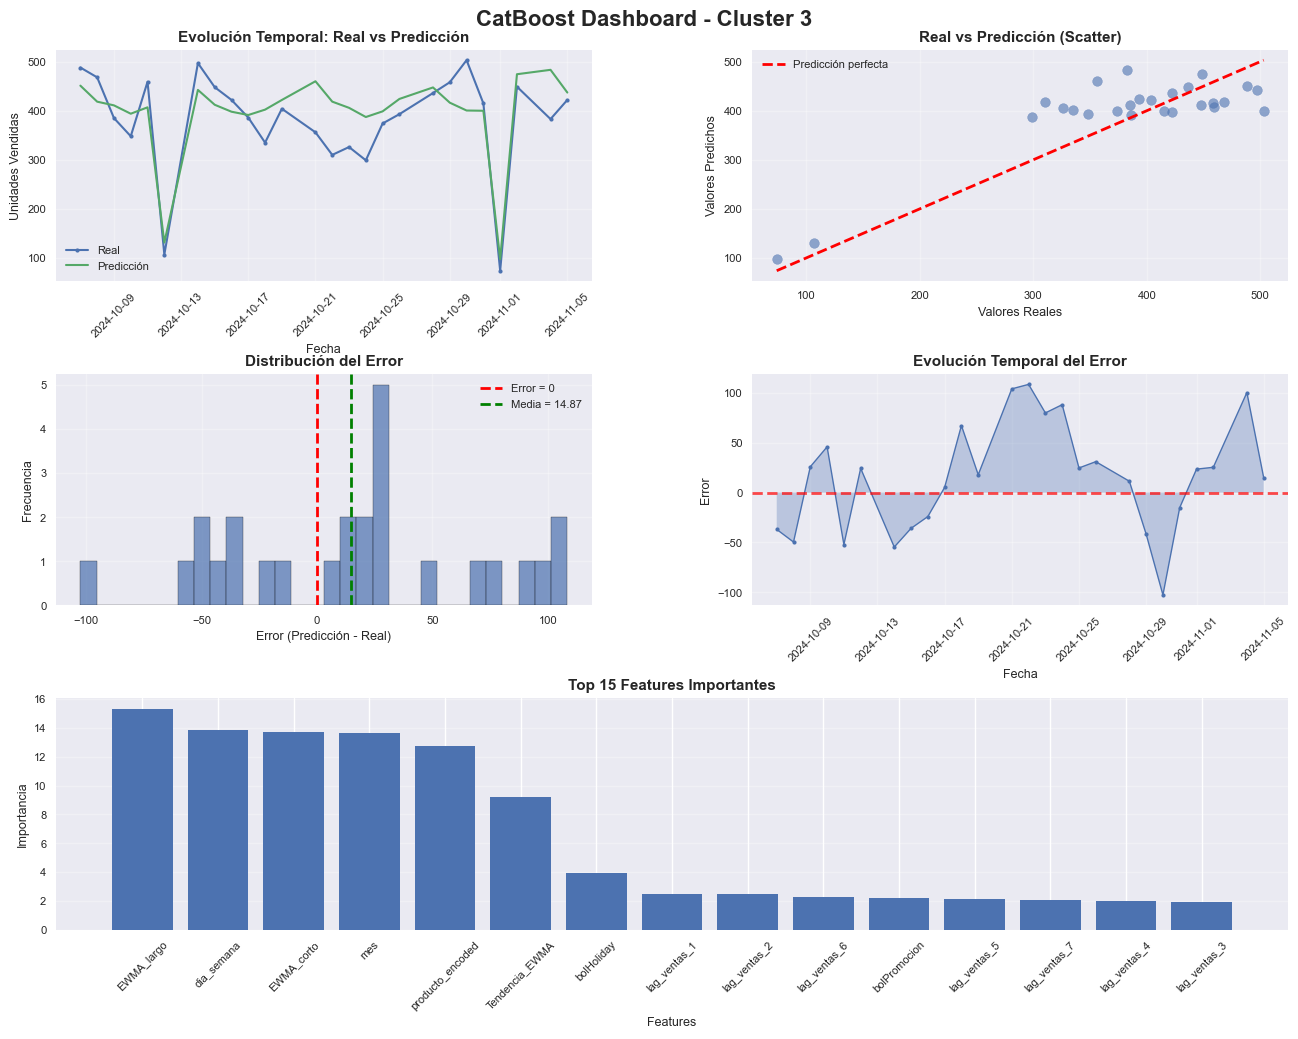

In [12]:

# ============================================================================
# 2. MODELOS POR CLUSTER
# ============================================================================

print("\n" + "="*100)
print("🔍 MODELO 2: CATBOOST POR CLUSTER")
print("="*100)

modelos_cluster = {}

for cluster in sorted(df_train['Cluster'].unique()):
    print(f"\n🔄 Entrenando modelo para Cluster {cluster}...")
    
    # Filtrar datos
    train_cluster = df_train[df_train['Cluster'] == cluster]
    test_cluster = df_test[df_test['Cluster'] == cluster].dropna()
    
    if len(test_cluster) == 0:
        print(f"   ⚠️  No hay datos de validación")
        continue
    
    X_train_c = train_cluster[FEATURES]
    y_train_c = train_cluster[TARGET]
    X_test_c = test_cluster[FEATURES]
    y_test_c = test_cluster[TARGET]
      
    # Entrenar
    catboost_cluster = CatBoostRegressor(
        **study_catboost.best_params,
        random_state=42)
    
    catboost_cluster.fit(X_train_c, y_train_c, verbose=False)
    y_pred_c = catboost_cluster.predict(X_test_c)
    
    # Calcular métricas
    metricas_cluster = calcular_metricas(
        y_test_c, y_pred_c,
        algoritmo="CatBoost", ndetalle='Cluster',cluster=cluster, producto=None)
    todas_metricas.append(metricas_cluster)
    
    
    # Calcular métricas por producto top en cada cluster
    top_productos = obtener_top_productos_por_cluster(
        df=train_cluster,
        col_ventas='udsVenta',
        col_cluster='Cluster',
        col_producto='producto',
        n_productos=2
    ) 
    
    for producto in top_productos.get(cluster, []):
        idx_producto = (test_cluster['producto'] == producto)
        y_test_prod = y_test_c[idx_producto]
        y_test_pred_prod = y_pred_c[idx_producto]
        metricas_producto = calcular_metricas(
            y_test_prod, y_test_pred_prod,
            algoritmo='CatBoost',
            ndetalle='Cluster', cluster=cluster, producto=producto)
        todas_metricas.append(metricas_producto)
    
    resumen_metricas([metricas_cluster])
    
    # Visualizaciones del modelo cluster
    df_test_viz = test_cluster.copy()
    df_test_viz['prediccion'] = y_pred_c
    df_test_viz_sum = df_test_viz.groupby('idSecuencia')[[TARGET, 'prediccion']].sum().reset_index()
    df_test_viz_sum['error'] = df_test_viz_sum['prediccion'] - df_test_viz_sum[TARGET]
    
    dashboard_prediccion(
        df=df_test_viz_sum,
        col_fecha='idSecuencia',
        col_real=TARGET,
        col_pred='prediccion',
        modelo=catboost_cluster,
        feature_names=FEATURES,
        titulo_principal=f'CatBoost Dashboard - Cluster {cluster}'
        )



# CatBoost por top 2 productos de ventas por cluster


📍 MODELO 3: XGBoost POR PRODUCTO TOP (2 POR CLUSTER)

🎯 CLUSTER 0 - Top 2 productos

🔄 Entrenando modelo para Producto 413 (Cluster 0)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        0       413 1.9187 2.3765 -0.1668     45.36     111.22 0.8319    92.38

🏆 Mejor modelo: CatBoost (RMSE: 2.3765)


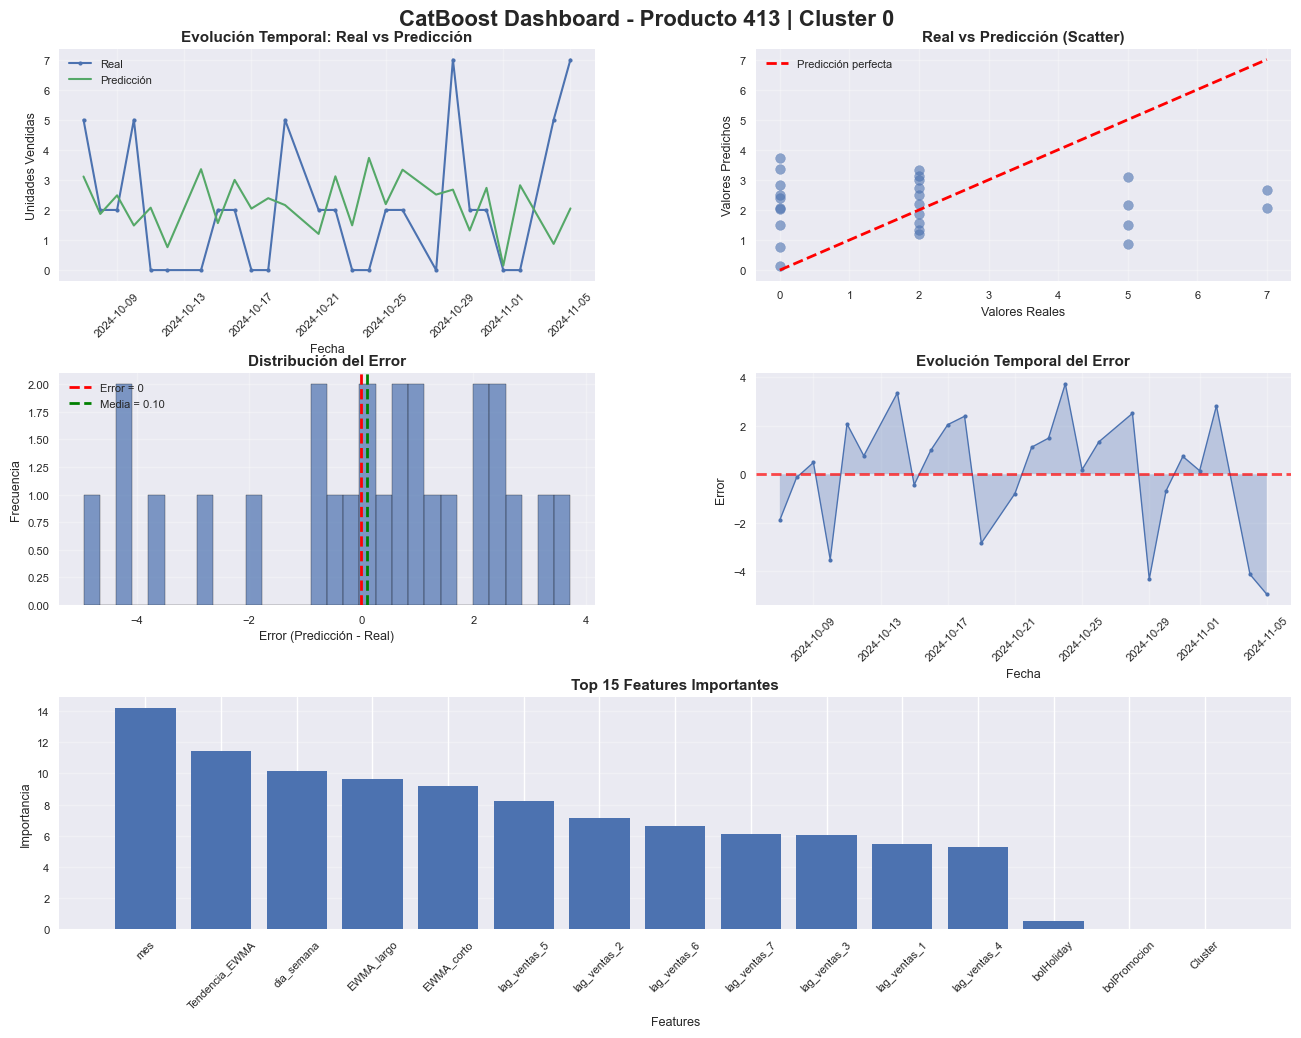


🔄 Entrenando modelo para Producto 294 (Cluster 0)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        0       294 2.5704 3.2834 -0.3516     73.91     143.09 0.7564   139.23

🏆 Mejor modelo: CatBoost (RMSE: 3.2834)


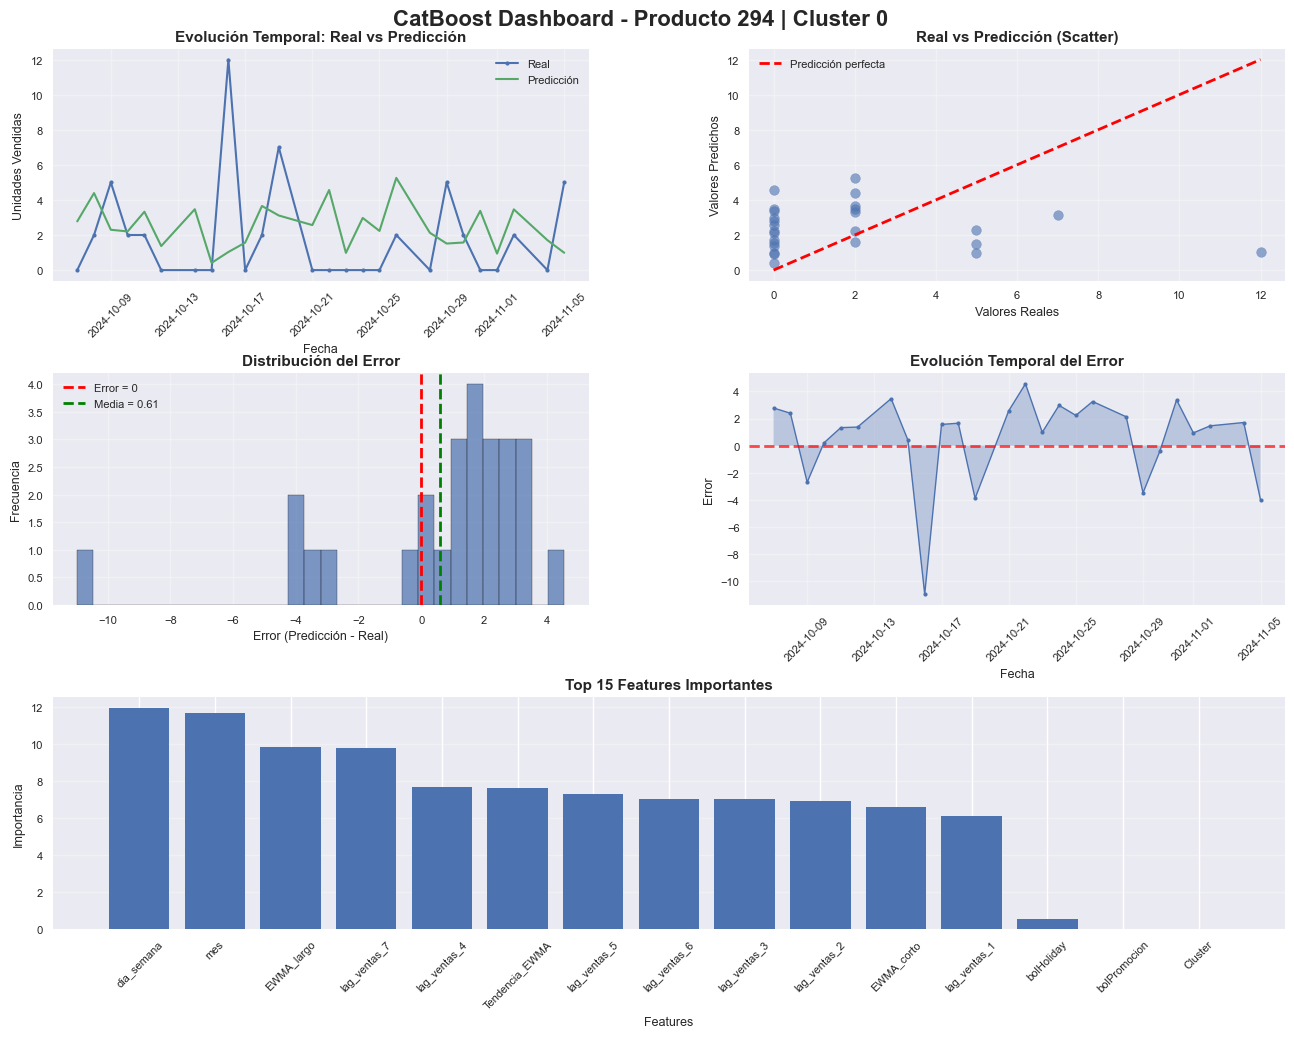


🎯 CLUSTER 1 - Top 2 productos

🔄 Entrenando modelo para Producto 144 (Cluster 1)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        1       144 3.9554 4.9565 0.0436     77.37      83.86 0.7409    69.96

🏆 Mejor modelo: CatBoost (RMSE: 4.9565)


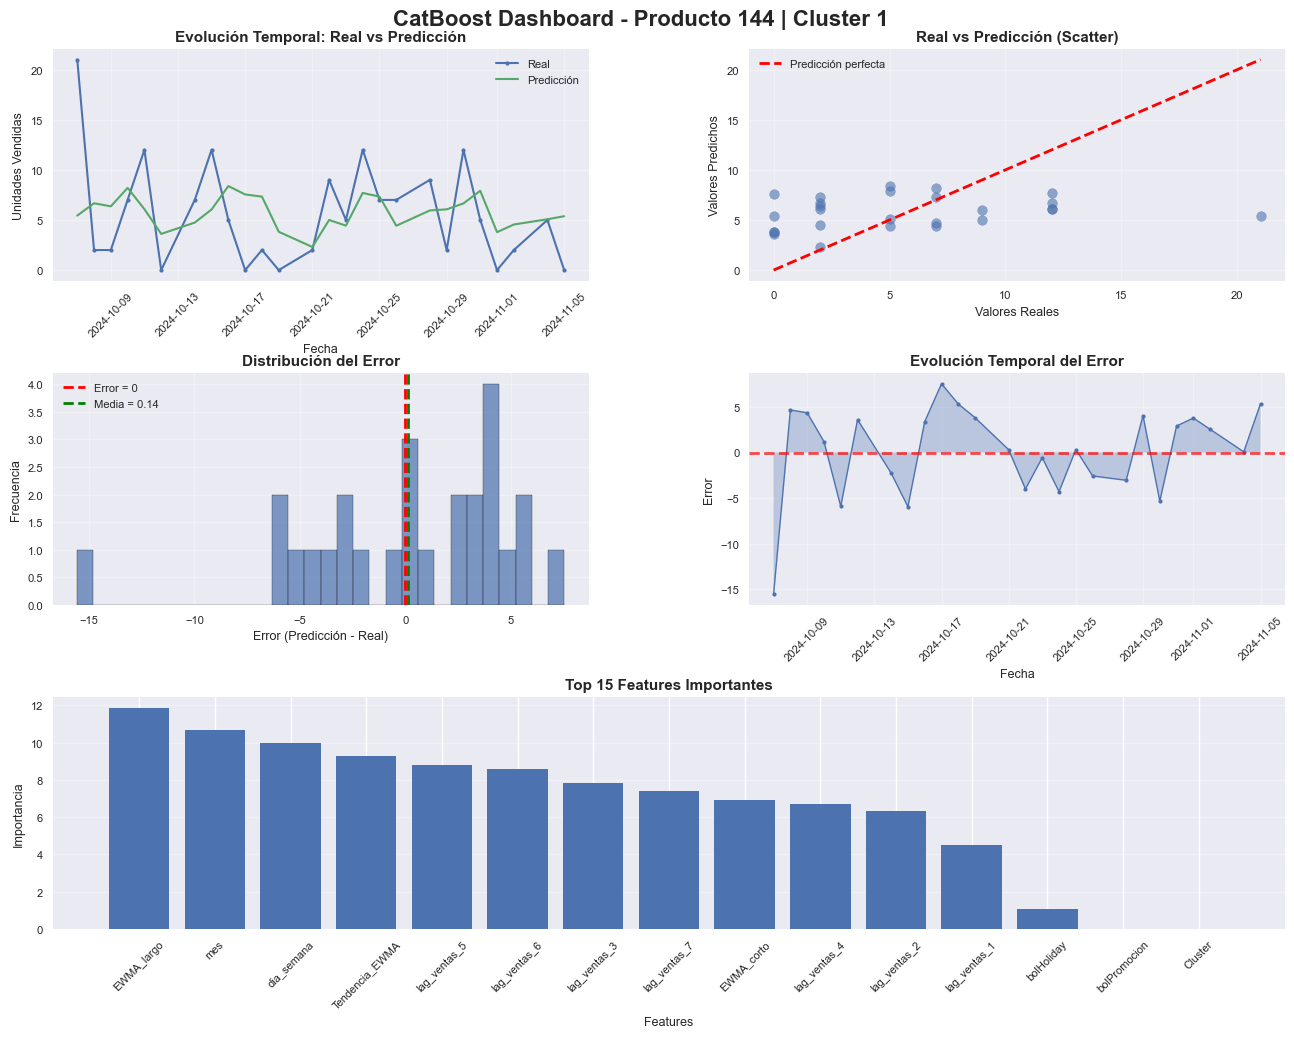


🔄 Entrenando modelo para Producto 41 (Cluster 1)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto   MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        1        41 3.665 4.7629 -0.1125     63.44      68.09  0.813     55.4

🏆 Mejor modelo: CatBoost (RMSE: 4.7629)


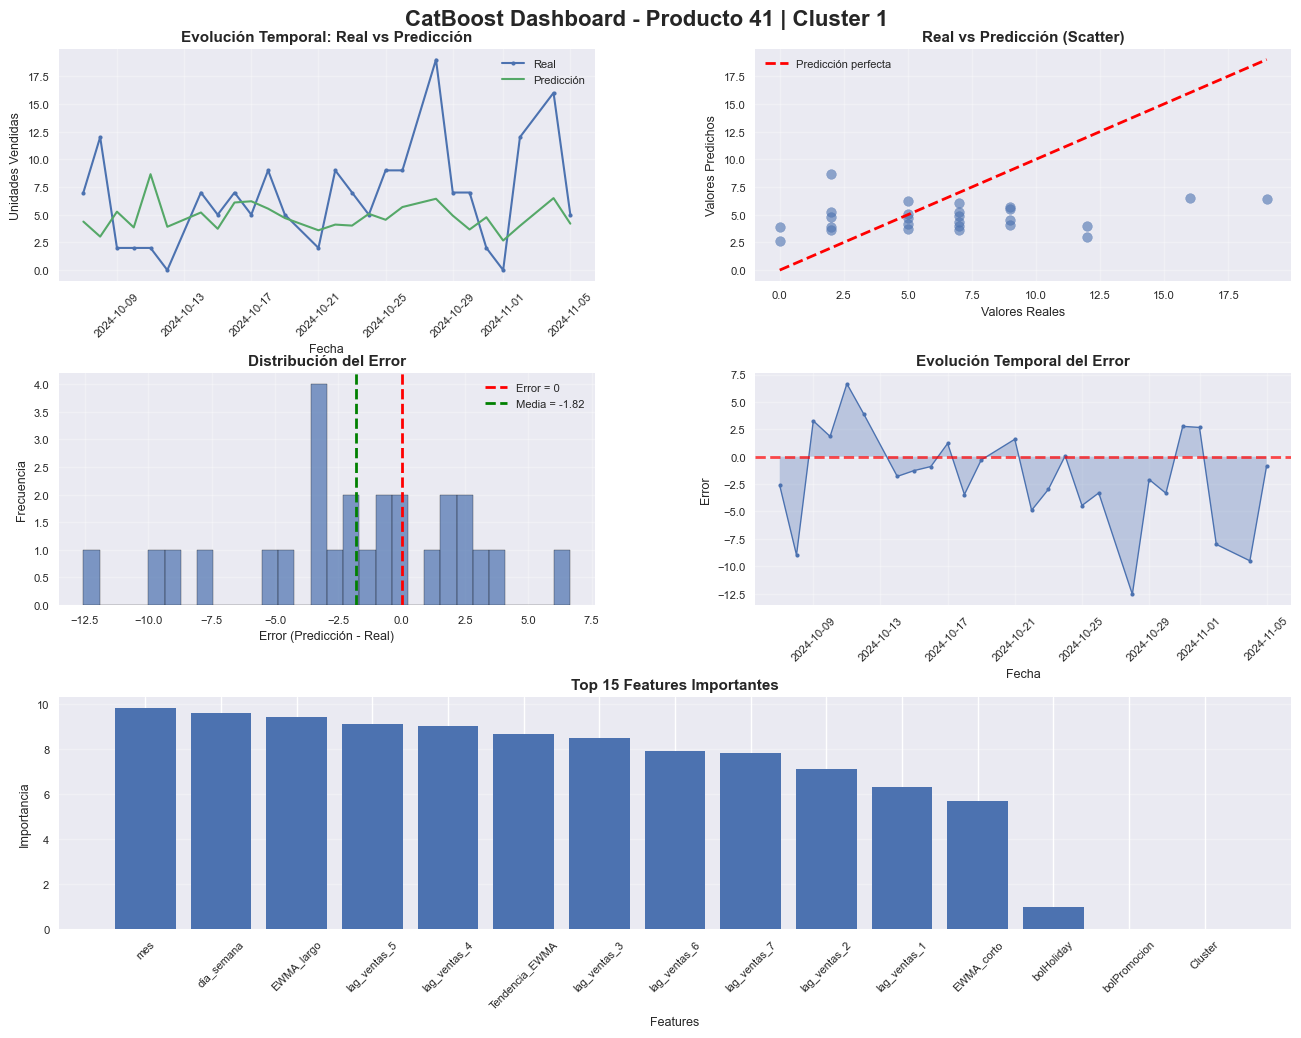


🎯 CLUSTER 2 - Top 2 productos

🔄 Entrenando modelo para Producto 1 (Cluster 2)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE    RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        2         1 8.3647 11.8462 -0.131    113.45      74.88 0.7458    70.84

🏆 Mejor modelo: CatBoost (RMSE: 11.8462)


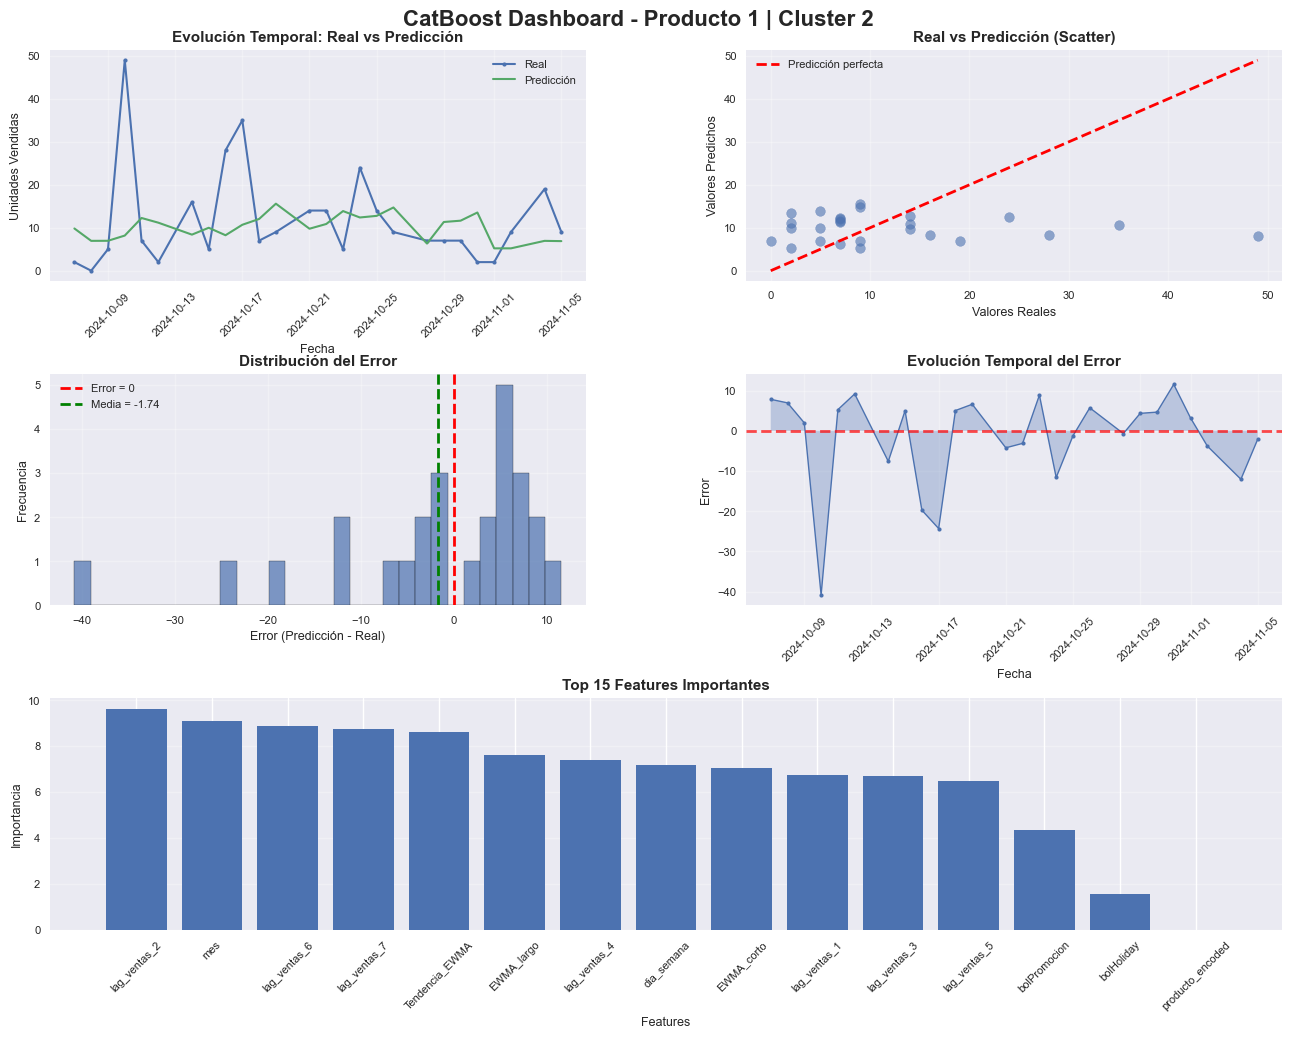


🔄 Entrenando modelo para Producto 2 (Cluster 2)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        2         2 3.7491 4.5818 -0.0269     84.07      68.13 0.6366    59.44

🏆 Mejor modelo: CatBoost (RMSE: 4.5818)


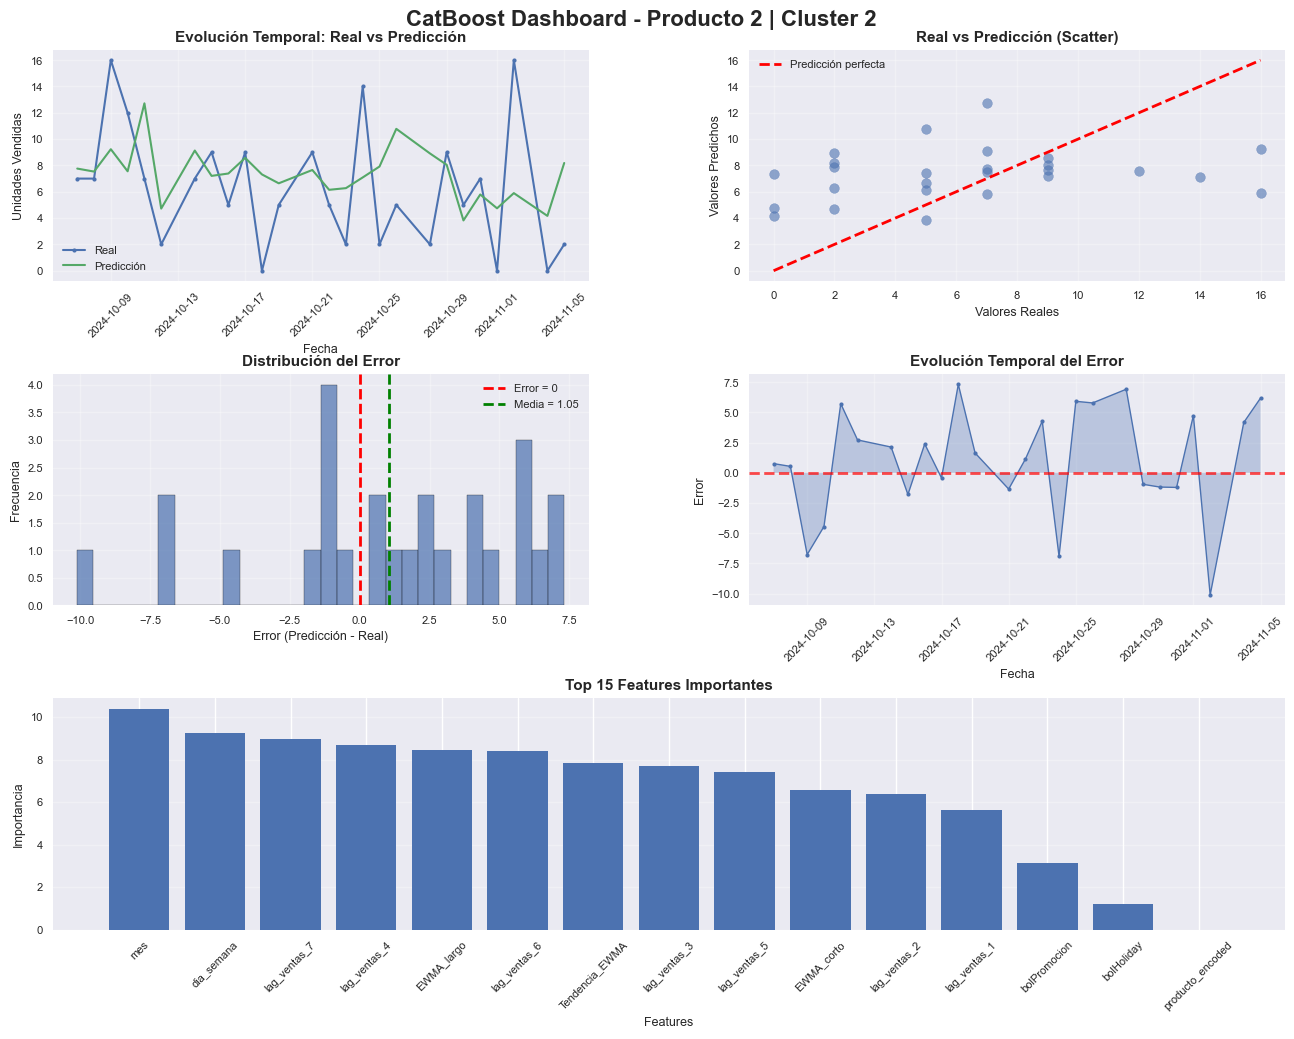


🎯 CLUSTER 3 - Top 2 productos

🔄 Entrenando modelo para Producto 257 (Cluster 3)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto   MAE   RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        3       257 1.158 1.6543 -1.0624     59.79      181.0 1.1256   231.59

🏆 Mejor modelo: CatBoost (RMSE: 1.6543)


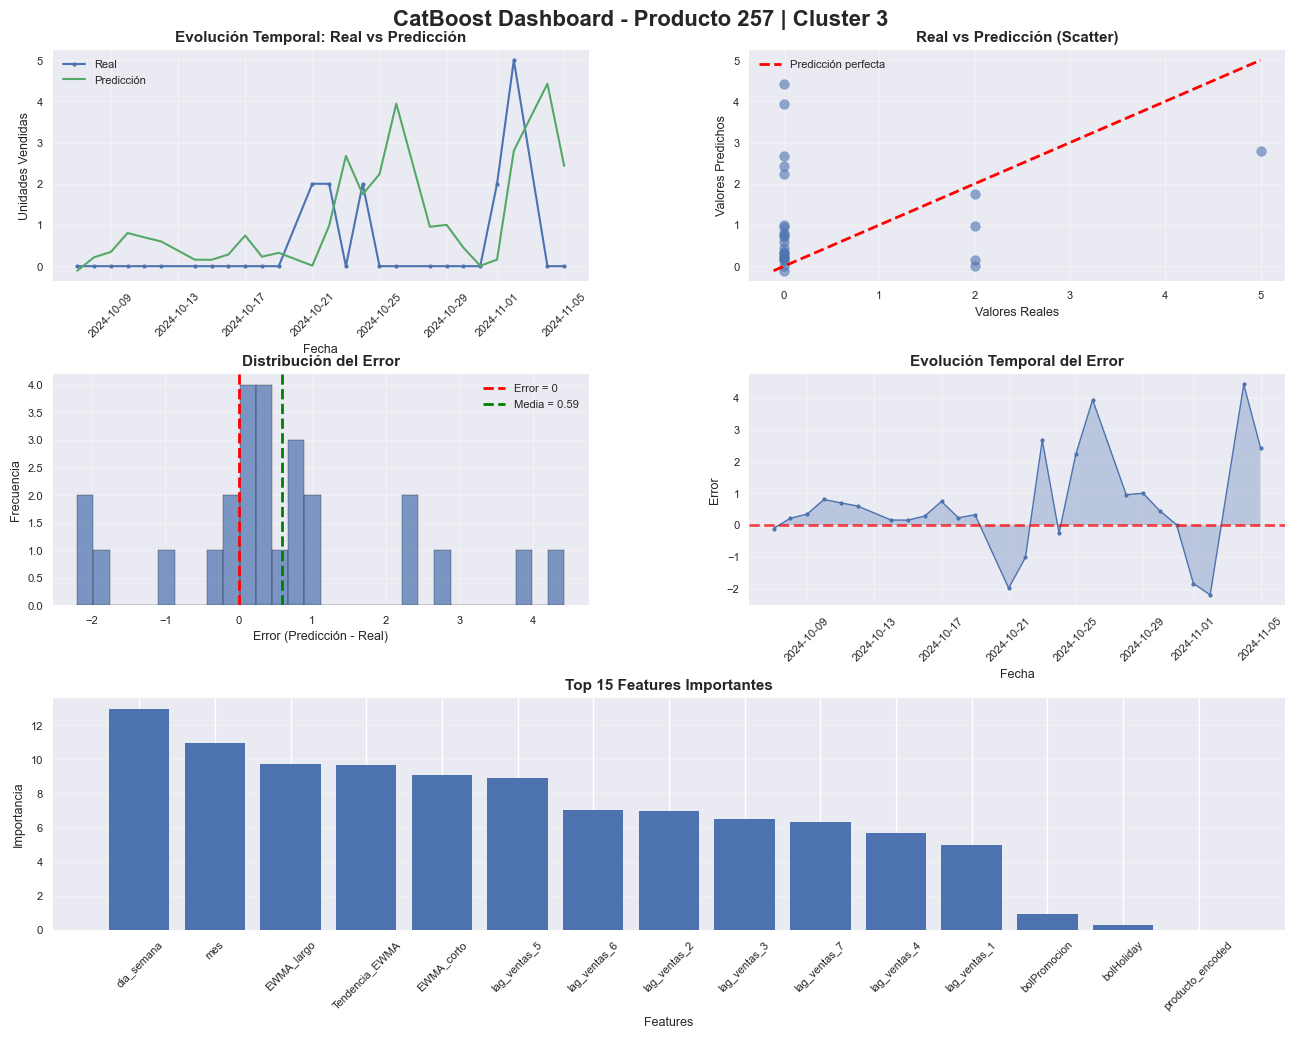


🔄 Entrenando modelo para Producto 314 (Cluster 3)...

📊 RESUMEN DE MÉTRICAS
Algoritmo NDetalle  Cluster  Producto    MAE   RMSE  R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost Producto        3       314 0.5767 0.6804 0.0       NaN      200.0    NaN      NaN

🏆 Mejor modelo: CatBoost (RMSE: 0.6804)


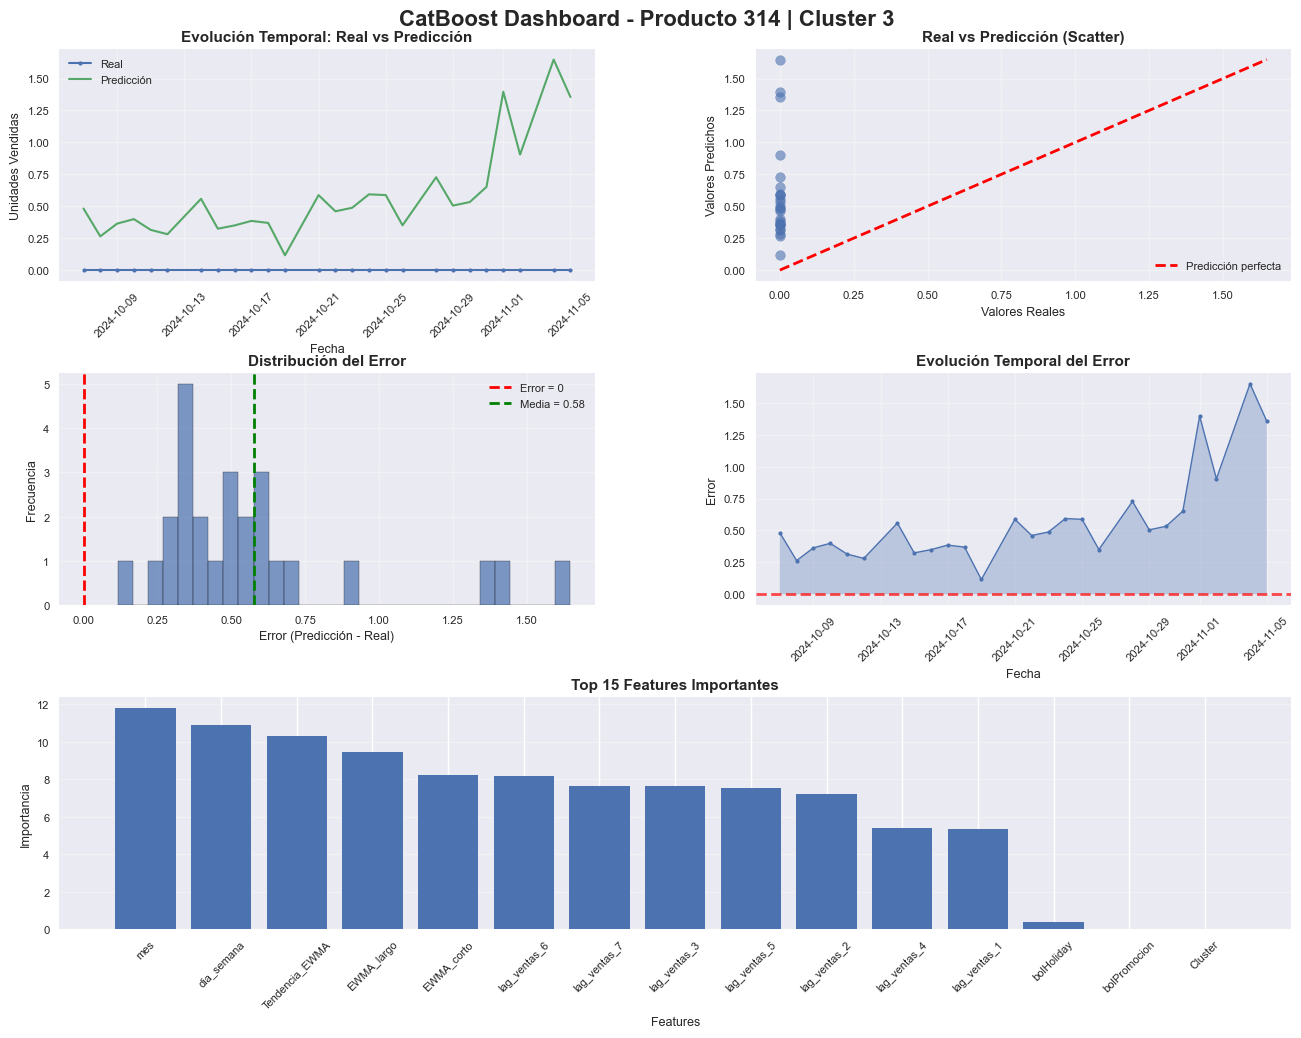


✅ Modelos por producto completados: 8 modelos entrenados


In [13]:
# ============================================================================
# 3. MODELOS POR PRODUCTO TOP (2 POR CLUSTER)
# ============================================================================

print("\n" + "="*100)
print("📍 MODELO 3: XGBoost POR PRODUCTO TOP (2 POR CLUSTER)")
print("="*100)

modelos_producto = {}

# Obtener los 2 productos top por cluster
productos_top_cluster = obtener_top_productos_por_cluster(
    df=df_train,
    col_ventas='udsVenta',
    col_cluster='Cluster',
    col_producto='producto',
    n_productos=2
)

# Iterar por cada cluster y sus productos top
for cluster, productos in productos_top_cluster.items():
    print(f"\n{'='*100}")
    print(f"🎯 CLUSTER {cluster} - Top {len(productos)} productos")
    print(f"{'='*100}")
    
    for producto in productos:
        print(f"\n🔄 Entrenando modelo para Producto {producto} (Cluster {cluster})...")
        
        # Filtrar datos por cluster y producto
        train_prod = df_train[(df_train['Cluster'] == cluster) & (df_train['producto'] == producto)]
        test_prod = df_test[(df_test['Cluster'] == cluster) & (df_test['producto'] == producto)].dropna()
        
        # Preparar características y target
        X_train_p = train_prod[FEATURES]
        y_train_p = train_prod[TARGET]
        X_test_p = test_prod[FEATURES]
        y_test_p = test_prod[TARGET]
        
        # Entrenar modelo con los mejores hiperparámetros de Optuna
        catboost_prod = CatBoostRegressor(
            **study_catboost.best_params,
            random_state=42)
        
        catboost_prod.fit(X_train_p, y_train_p, verbose=False)
        y_pred_p = catboost_prod.predict(X_test_p)
        
        # Guardar modelo
        modelos_producto[f"C{cluster}_P{producto}"] = catboost_prod
        
        # Calcular métricas y GUARDAR
        metricas_producto = calcular_metricas(
            y_test_p, y_pred_p,
            algoritmo="CatBoost",
            ndetalle='Producto', cluster=cluster, producto=producto)
        todas_metricas.append(metricas_producto)
        resumen_metricas([metricas_producto])
                
        # Preparar datos para visualización
        test_prod_pred = test_prod.copy()
        test_prod_pred['prediccion'] = y_pred_p
        test_prod_pred['error'] = y_pred_p - test_prod_pred[TARGET]
        test_prod_pred['error_abs'] = np.abs(test_prod_pred['error'])
        test_prod_pred['error_pct'] = (test_prod_pred['error_abs'] / (test_prod_pred[TARGET] + 1e-10)) * 100
        test_prod_pred = test_prod_pred.sort_values('idSecuencia')
        
        # Dashboard de predicción
        dashboard_prediccion(
            df=test_prod_pred,
            col_fecha='idSecuencia',
            col_real=TARGET,
            col_pred='prediccion',
            modelo=catboost_prod,
            feature_names=FEATURES,
            titulo_principal=f'CatBoost Dashboard - Producto {producto} | Cluster {cluster}'
            )

print(f"\n{'='*100}")
print(f"✅ Modelos por producto completados: {len(modelos_producto)} modelos entrenados")
print(f"{'='*100}")


# Resumen final

In [14]:
# Ejecutar el resumen final usando la función de la librería
resumen_final_modelos(todas_metricas)


🏆 RESUMEN FINAL - COMPARACIÓN DE TODOS LOS MODELOS

📊 Resumen de todas las métricas (todas las columnas):
Algoritmo NDetalle  Cluster  Producto    MAE      MSE    RMSE      R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
 CatBoost  Cluster      3.0     314.0 0.3474   0.1393  0.3732  0.0000       NaN     200.00    NaN      NaN
 CatBoost  Cluster      3.0     257.0 0.8691   1.3315  1.1539 -0.0035     75.08     185.42 0.7851   173.83
 CatBoost  Cluster      3.0       NaN 1.0833   2.7254  1.6509  0.0868     55.31     168.99 0.7408   133.39
 CatBoost  Cluster      0.0     413.0 1.7250   4.7534  2.1802  0.0179     34.59     102.63 0.7632    83.06
 CatBoost  Cluster      0.0       NaN 1.8073   6.4528  2.5402  0.1234     39.88     125.83 0.7302    93.60
 CatBoost  Cluster      0.0     294.0 2.1790   8.2351  2.8697 -0.0324     38.88     130.72 0.6611   118.03
 CatBoost  Cluster      1.0       NaN 2.7666  12.8576  3.5857  0.1448     55.30      98.60 0.7167    72.55
 CatBoost  Cluster      1.0      41.0

# Salvar resultados

In [15]:

# Salvar resultados en fichero
df_resultados = pd.DataFrame(todas_metricas)
df_resultados.to_csv('datos/resultados_metricas_catboost.csv', index=False)
print("\nResultados guardados en 'datos/resultados_metricas_catboost.csv'")


Resultados guardados en 'datos/resultados_metricas_catboost.csv'
